# 91 — STH-SOPR Intraday Mean Reversion

**Hypothesis**: When STH-SOPR drops below 0.95 on hourly data (acute capitulation), price bounces as selling exhausts.

## Strategy
- **Resolution**: Hourly / H4
- **Entry**: STH-SOPR < threshold (0.90, 0.93, 0.95, 0.97)
- **Exit**: STH-SOPR crosses back above 1.0 (holders back in profit) OR stop loss OR time stop
- **Risk**: High — capitulation can continue much further in real crashes
- **Period**: 2020-02-02 → present

In [1]:
import pandas as pd
import numpy as np
import vectorbt as vbt
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('.').resolve().parent
BL_HOURLY = PROJECT_ROOT / 'data' / 'bl' / 'hourly'
BL_H4 = PROJECT_ROOT / 'data' / 'bl' / 'h4'
GN_HOURLY = PROJECT_ROOT / 'data' / 'glassnode' / 'hourly'

BACKTEST_START = '2020-02-02'
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/fester/Documents/bitcoin-lab-btc-data-pipeline


## 1. Data Loading

In [2]:
def load_parquet(path: Path) -> pd.Series:
    if not path.exists():
        print(f'WARNING: {path} not found')
        return pd.Series(dtype=float)
    df = pd.read_parquet(path)
    time_col = next((c for c in ['time', 'date', 'timestamp'] if c in df.columns), None)
    if time_col is None and isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        time_col = df.columns[0]
    val_col = 'value' if 'value' in df.columns else next((c for c in df.columns if c not in ['time', 'date', 'timestamp']), None)
    s = df.set_index(time_col)[val_col].sort_index()
    s.index = pd.to_datetime(s.index)
    if s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s.astype(float)


# Load both resolutions
datasets = {}
for name, bl_dir, freq in [('hourly', BL_HOURLY, '1h'), ('h4', BL_H4, '4h')]:
    price = load_parquet(bl_dir / 'price.parquet').loc[BACKTEST_START:]
    sopr_sth = load_parquet(bl_dir / 'sopr_sth.parquet')
    mvrv_sth = load_parquet(bl_dir / 'mvrv_sth.parquet')
    
    idx = price.index
    df = pd.DataFrame(index=idx)
    df['price'] = price
    df['sopr_sth'] = sopr_sth.reindex(idx, method='ffill')
    df['mvrv_sth'] = mvrv_sth.reindex(idx, method='ffill')
    df = df.dropna(subset=['price'])
    
    datasets[name] = {'df': df, 'freq': freq}
    print(f'{name:8s}: {len(df):>7,} bars | {df.index[0]} → {df.index[-1]}')
    print(f'         SOPR STH range: {df["sopr_sth"].min():.4f} — {df["sopr_sth"].max():.4f} | nulls: {df["sopr_sth"].isna().sum()}')

hourly  :  52,391 bars | 2020-02-02 00:00:00 → 2026-01-30 11:00:00
         SOPR STH range: 0.6023 — 2.3364 | nulls: 0
h4      :  13,137 bars | 2020-02-02 00:00:00 → 2026-01-30 08:00:00
         SOPR STH range: 0.7116 — 1.4674 | nulls: 0


## 2. STH-SOPR Distribution & Capitulation Events

In [3]:
# Distribution of STH-SOPR values
for name, ds in datasets.items():
    df = ds['df']
    print(f'\n{name.upper()} STH-SOPR:')
    print(f'  Mean: {df["sopr_sth"].mean():.4f}')
    print(f'  Percentiles:')
    for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        val = df['sopr_sth'].quantile(pct/100)
        print(f'    {pct:>3}th: {val:.4f}')
    
    # Count bars below key thresholds
    print(f'  Bars below thresholds:')
    for thresh in [0.90, 0.93, 0.95, 0.97, 1.00]:
        n = (df['sopr_sth'] < thresh).sum()
        pct = n / len(df) * 100
        print(f'    < {thresh}: {n:>6} bars ({pct:.1f}%)')


HOURLY STH-SOPR:
  Mean: 1.0049
  Percentiles:
      1th: 0.9189
      5th: 0.9652
     10th: 0.9791
     25th: 0.9936
     50th: 1.0021
     75th: 1.0133
     90th: 1.0328
     95th: 1.0513
     99th: 1.1148
  Bars below thresholds:
    < 0.9:    318 bars (0.6%)
    < 0.93:    733 bars (1.4%)
    < 0.95:   1441 bars (2.8%)
    < 0.97:   3259 bars (6.2%)
    < 1.0:  22481 bars (42.9%)

H4 STH-SOPR:
  Mean: 1.0050
  Percentiles:
      1th: 0.9307
      5th: 0.9687
     10th: 0.9809
     25th: 0.9938
     50th: 1.0022
     75th: 1.0139
     90th: 1.0318
     95th: 1.0479
     99th: 1.1043
  Bars below thresholds:
    < 0.9:     45 bars (0.3%)
    < 0.93:    128 bars (1.0%)
    < 0.95:    271 bars (2.1%)
    < 0.97:    705 bars (5.4%)
    < 1.0:   5589 bars (42.5%)


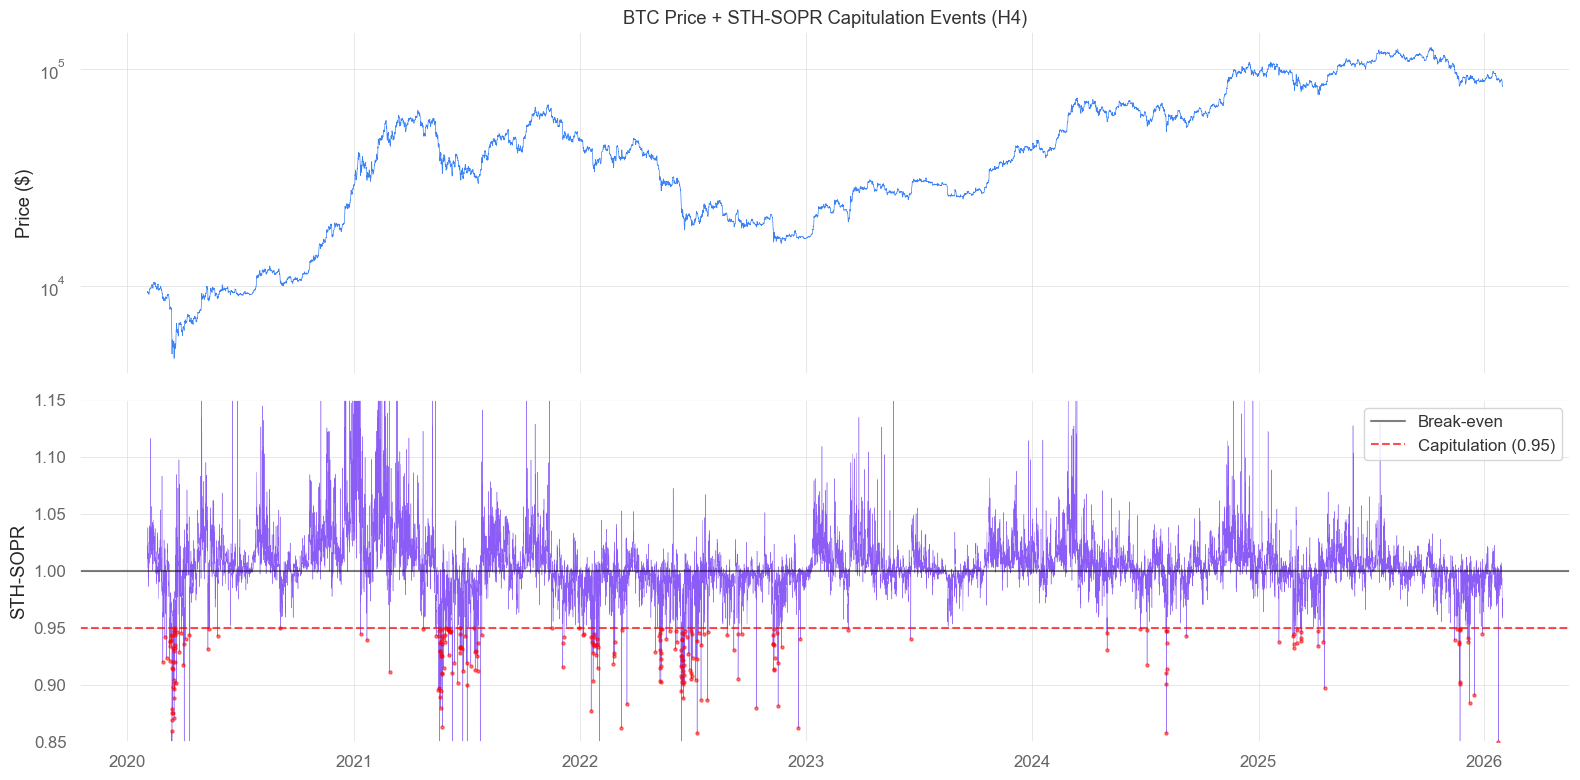

In [4]:
# Visualize STH-SOPR with price
df_h4 = datasets['h4']['df']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df_h4.index, df_h4['price'], color='#3b82f6', linewidth=0.5)
axes[0].set_ylabel('Price ($)')
axes[0].set_title('BTC Price + STH-SOPR Capitulation Events (H4)')
axes[0].set_yscale('log')

axes[1].plot(df_h4.index, df_h4['sopr_sth'], color='#8b5cf6', linewidth=0.3)
axes[1].axhline(1.0, color='black', linestyle='-', alpha=0.5, label='Break-even')
axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Capitulation (0.95)')
cap = df_h4[df_h4['sopr_sth'] < 0.95]
axes[1].scatter(cap.index, cap['sopr_sth'], color='red', s=5, zorder=5, alpha=0.5)
axes[1].set_ylabel('STH-SOPR')
axes[1].set_ylim(0.85, 1.15)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Forward Returns After Capitulation

In [5]:
# Forward returns at various horizons for H4 resolution
df_h4 = datasets['h4']['df'].copy()

# Forward returns in H4 bars (multiply by 4 for hours)
for bars in [1, 3, 6, 12, 18, 36, 72]:  # 4h, 12h, 24h, 48h, 72h, 6d, 12d
    df_h4[f'fwd_{bars}b'] = df_h4['price'].pct_change(bars).shift(-bars) * 100

print('Forward returns after STH-SOPR capitulation (H4 bars):')
print('=' * 100)
print(f'{"Threshold":>10s}  |  {"4h":>7s}  {"12h":>7s}  {"24h":>7s}  {"48h":>7s}  {"72h":>7s}  {"6d":>7s}  {"12d":>7s}  |  {"N":>5}')
print('-' * 100)

bar_labels = [1, 3, 6, 12, 18, 36, 72]

for thresh in [0.90, 0.93, 0.95, 0.97, 1.00]:
    mask = df_h4['sopr_sth'] < thresh
    n = mask.sum()
    print(f'  < {thresh:.2f}  |', end='')
    for bars in bar_labels:
        ret = df_h4.loc[mask, f'fwd_{bars}b'].mean()
        print(f'  {ret:>+6.2f}%', end='')
    print(f'  |  {n:>5}')

# Baseline (all bars)
print(f'  All bars |', end='')
for bars in bar_labels:
    ret = df_h4[f'fwd_{bars}b'].mean()
    print(f'  {ret:>+6.2f}%', end='')
print(f'  |  {len(df_h4):>5}')

Forward returns after STH-SOPR capitulation (H4 bars):
 Threshold  |       4h      12h      24h      48h      72h       6d      12d  |      N
----------------------------------------------------------------------------------------------------
  < 0.90  |   +0.01%   +0.08%   +1.31%   +0.04%   +0.29%   +3.84%   +7.99%  |     45
  < 0.93  |   -0.21%   +0.07%   +0.83%   +0.54%   +0.45%   +2.65%   +5.11%  |    128
  < 0.95  |   -0.27%   -0.11%   +0.24%   +0.40%   +0.67%   +1.97%   +3.36%  |    271
  < 0.97  |   -0.19%   -0.15%   +0.07%   +0.22%   +0.40%   +0.90%   +1.80%  |    705
  < 1.00  |   -0.08%   -0.05%   -0.01%   +0.04%   +0.13%   +0.42%   +1.09%  |   5589
  All bars |   +0.02%   +0.07%   +0.15%   +0.30%   +0.45%   +0.92%   +1.85%  |  13137


## 4. VectorBT Backtest — SOPR Mean Reversion

**Entry**: STH-SOPR < threshold
**Exit**: STH-SOPR crosses back above 1.0 OR stop loss OR time stop

In [6]:
def run_sopr_backtest(df, freq, sopr_entry, sopr_exit=1.0, sl_pct=None, time_stop_bars=None):
    """Backtest STH-SOPR mean reversion.
    
    Entry: sopr_sth < sopr_entry
    Exit: sopr_sth >= sopr_exit OR stop loss
    """
    price = df['price'].copy()
    sopr = df['sopr_sth'].copy()
    
    entries = sopr < sopr_entry
    exits = sopr >= sopr_exit
    
    if entries.sum() == 0:
        return None
    
    kwargs = dict(
        close=price,
        entries=entries,
        exits=exits,
        fees=0.001,
        slippage=0.001,
        init_cash=10_000,
        freq=freq,
    )
    
    if sl_pct is not None:
        kwargs['sl_stop'] = sl_pct / 100
    
    pf = vbt.Portfolio.from_signals(**kwargs)
    
    n_trades = pf.trades.count()
    if n_trades == 0:
        return None
    
    return {
        'sopr_entry': sopr_entry,
        'sopr_exit': sopr_exit,
        'sl_pct': sl_pct,
        'time_stop': time_stop_bars,
        'freq': freq,
        'total_return': pf.total_return() * 100,
        'sharpe': pf.sharpe_ratio(),
        'max_dd': pf.max_drawdown() * 100,
        'n_trades': n_trades,
        'win_rate': pf.trades.win_rate() * 100,
        'avg_trade': pf.trades.returns.mean() * 100,
        'portfolio': pf,
    }


# Grid search on H4
sopr_entries = [0.90, 0.93, 0.95, 0.97]
sopr_exits = [1.00, 1.02, 1.05]
sl_levels = [None, 3, 5, 10]

grid_results = []
df_h4 = datasets['h4']['df']

for entry, exit_val, sl in product(sopr_entries, sopr_exits, sl_levels):
    r = run_sopr_backtest(df_h4, '4h', entry, exit_val, sl)
    if r is not None:
        grid_results.append(r)

print(f'Grid search: {len(grid_results)} valid results')

# Also test hourly
hourly_results = []
df_hr = datasets['hourly']['df']

for entry, exit_val, sl in product(sopr_entries, sopr_exits, [None, 5]):
    r = run_sopr_backtest(df_hr, '1h', entry, exit_val, sl)
    if r is not None:
        hourly_results.append(r)

print(f'Hourly grid: {len(hourly_results)} valid results')

Grid search: 48 valid results


Hourly grid: 24 valid results


In [7]:
# Results table — H4, sorted by Sharpe
all_results = grid_results + hourly_results
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'portfolio'} for r in all_results])
results_df = results_df.sort_values('sharpe', ascending=False)

print('Top 20 configurations by Sharpe ratio (H4 + Hourly):')
print('=' * 130)
print(f'{"Freq":>5s}  {"Entry":>6s}  {"Exit":>5s}  {"SL%":>5s}  |  {"Return":>9s}  {"Sharpe":>7s}  {"MaxDD":>8s}  {"Trades":>7s}  {"WinRate":>8s}  {"AvgTrade":>9s}')
print('-' * 130)

for _, row in results_df.head(20).iterrows():
    sl_str = f'{row["sl_pct"]:.0f}' if row['sl_pct'] is not None and row['sl_pct'] == row['sl_pct'] else 'None'
    print(f'{row["freq"]:>5s}  {row["sopr_entry"]:>6.2f}  {row["sopr_exit"]:>5.2f}  {sl_str:>5s}  |  '
          f'{row["total_return"]:>+8.1f}%  {row["sharpe"]:>7.2f}  {row["max_dd"]:>7.1f}%  '
          f'{row["n_trades"]:>7.0f}  {row["win_rate"]:>7.1f}%  {row["avg_trade"]:>+8.2f}%')

Top 20 configurations by Sharpe ratio (H4 + Hourly):
 Freq   Entry   Exit    SL%  |     Return   Sharpe     MaxDD   Trades   WinRate   AvgTrade
----------------------------------------------------------------------------------------------------------------------------------
   4h    0.90   1.05      5  |     +72.1%     0.53    -28.3%       26     42.3%     +2.82%
   4h    0.90   1.05   None  |     +78.9%     0.49    -34.4%       12     66.7%     +5.47%
   4h    0.90   1.02      5  |     +46.8%     0.48    -26.1%       29     55.2%     +1.67%
   4h    0.90   1.02   None  |     +58.8%     0.47    -29.4%       20     75.0%     +2.62%
   1h    0.93   1.05   None  |     +71.7%     0.43    -66.5%       72     69.4%     +1.20%
   1h    0.95   1.05   None  |     +52.2%     0.38    -70.4%      104     64.4%     +0.76%
   4h    0.90   1.05      3  |     +40.9%     0.37    -31.2%       28     35.7%     +1.78%
   1h    0.93   1.02   None  |     +50.0%     0.37    -48.0%      170     62.4%     +0.3

## 5. Best Configuration Deep Dive

In [8]:
best = max(all_results, key=lambda r: r['sharpe'] if r['sharpe'] == r['sharpe'] else -999)
pf_best = best['portfolio']

print(f'Best configuration:')
print(f'  Resolution:  {best["freq"]}')
print(f'  SOPR entry:  < {best["sopr_entry"]}')
print(f'  SOPR exit:   >= {best["sopr_exit"]}')
print(f'  Stop loss:   {best["sl_pct"]}%')
print(f'\nPerformance:')
print(f'  Total return: {best["total_return"]:+.1f}%')
print(f'  Sharpe ratio: {best["sharpe"]:.2f}')
print(f'  Max drawdown: {best["max_dd"]:.1f}%')
print(f'  Trades:       {best["n_trades"]}')
print(f'  Win rate:     {best["win_rate"]:.1f}%')
print(f'  Avg trade:    {best["avg_trade"]:+.2f}%')

trades = pf_best.trades.records_readable
if len(trades) > 0:
    print(f'\nTrade log (first 20):')
    cols = [c for c in ['Entry Timestamp', 'Exit Timestamp', 'PnL', 'Return', 'Status'] if c in trades.columns]
    print(trades[cols].head(20).to_string())

Best configuration:
  Resolution:  4h
  SOPR entry:  < 0.9
  SOPR exit:   >= 1.05
  Stop loss:   5%

Performance:
  Total return: +72.1%
  Sharpe ratio: 0.53
  Max drawdown: -28.3%
  Trades:       26
  Win rate:     42.3%
  Avg trade:    +2.82%

Trade log (first 20):
       Entry Timestamp      Exit Timestamp          PnL    Return  Status
0  2020-03-12 08:00:00 2020-03-12 16:00:00  -649.143250 -0.064979  Closed
1  2020-03-12 20:00:00 2020-03-13 00:00:00  -578.480595 -0.061926  Closed
2  2020-03-13 04:00:00 2020-03-16 04:00:00  -493.572178 -0.056321  Closed
3  2020-03-16 08:00:00 2020-03-20 08:00:00  3712.002408  0.448823  Closed
4  2020-04-01 16:00:00 2020-04-06 04:00:00  1509.898878  0.126047  Closed
5  2020-04-10 16:00:00 2020-04-23 12:00:00  1079.811094  0.080062  Closed
6  2021-05-17 00:00:00 2021-05-19 00:00:00 -1306.926902 -0.089725  Closed
7  2021-05-19 08:00:00 2021-05-21 16:00:00  -811.200510 -0.061175  Closed
8  2021-05-23 12:00:00 2021-06-21 20:00:00  -751.528792 -0.060364 

## 6. Equity Curve

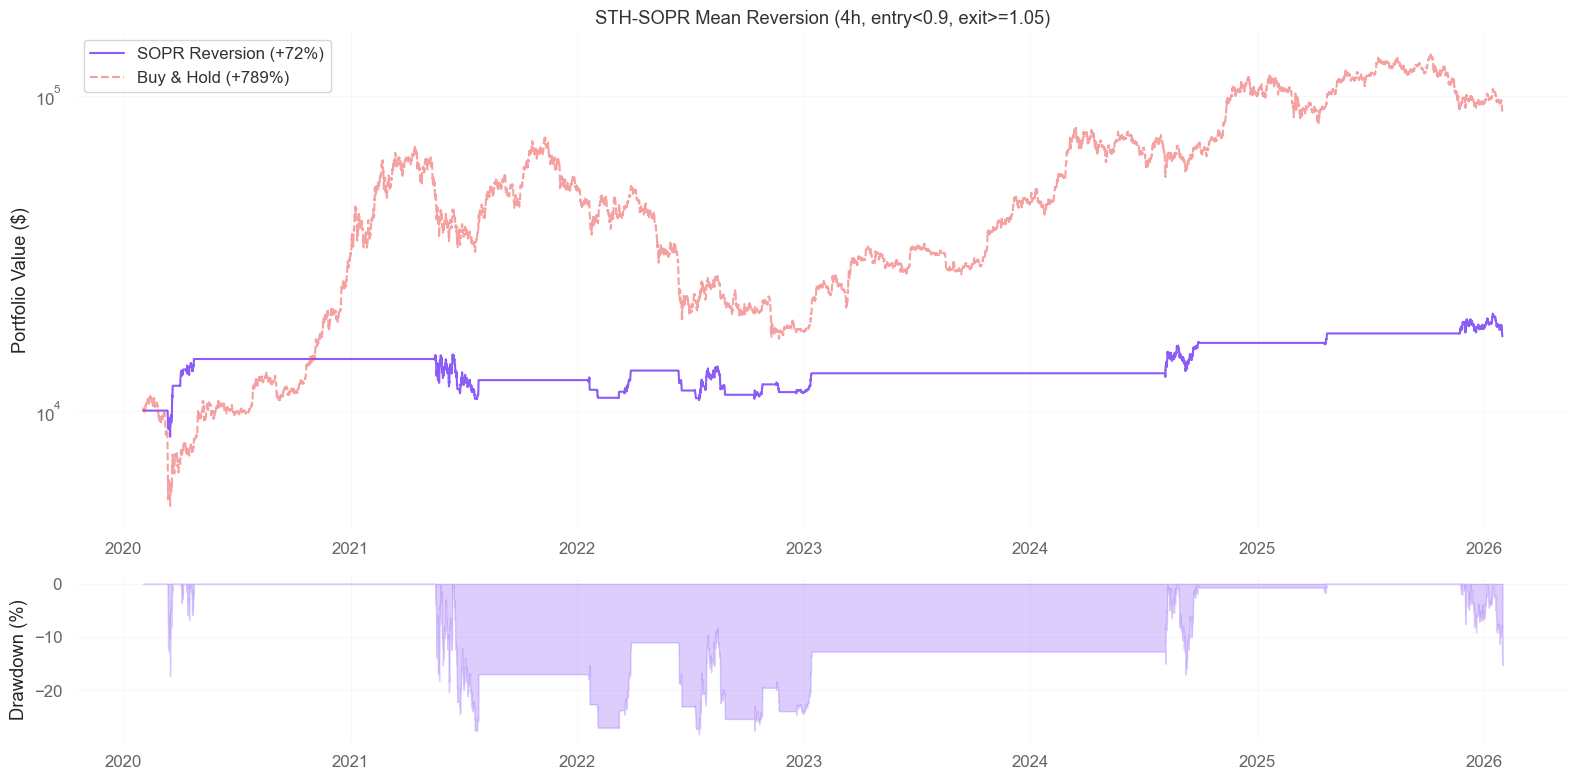

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

equity = pf_best.value()
price_series = datasets[best['freq'].replace('1h','hourly').replace('4h','h4')]['df']['price']
bh = 10_000 * price_series / price_series.iloc[0]

axes[0].plot(equity.index, equity.values, color='#8b5cf6',
             label=f'SOPR Reversion ({best["total_return"]:+.0f}%)')
axes[0].plot(bh.index, bh.values, color='#ef4444', linestyle='--', alpha=0.5,
             label=f'Buy & Hold ({(bh.iloc[-1]/10000-1)*100:+.0f}%)')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title(f'STH-SOPR Mean Reversion ({best["freq"]}, entry<{best["sopr_entry"]}, exit>={best["sopr_exit"]})')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

dd = pf_best.drawdown()
axes[1].fill_between(dd.index, dd.values * 100, 0, color='#8b5cf6', alpha=0.3)
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Regime Analysis — Bull vs Bear

In [10]:
# Split by market regime using 200-day MA
df_analysis = datasets['h4']['df'].copy()
df_analysis['ma200'] = df_analysis['price'].rolling(200 * 6, min_periods=100).mean()  # 200 days in h4 bars
df_analysis['bull'] = df_analysis['price'] > df_analysis['ma200']

for regime, label in [(True, 'BULL (price > 200d MA)'), (False, 'BEAR (price < 200d MA)')]:
    mask = df_analysis['bull'] == regime
    cap_mask = mask & (df_analysis['sopr_sth'] < best['sopr_entry'])
    
    # Forward 48h return (12 h4 bars)
    fwd = df_analysis['price'].pct_change(12).shift(-12) * 100
    
    cap_ret = fwd[cap_mask].dropna()
    all_ret = fwd[mask].dropna()
    
    print(f'{label}:')
    print(f'  Capitulation events: {cap_mask.sum()}')
    if len(cap_ret) > 0:
        print(f'  48h fwd return: {cap_ret.mean():+.2f}% (win rate: {(cap_ret>0).mean()*100:.1f}%)')
        print(f'  vs baseline:    {all_ret.mean():+.2f}%')
    print()

BULL (price > 200d MA):
  Capitulation events: 3
  48h fwd return: -4.11% (win rate: 33.3%)
  vs baseline:    +0.40%

BEAR (price < 200d MA):
  Capitulation events: 42
  48h fwd return: +0.33% (win rate: 64.3%)
  vs baseline:    +0.13%



## 8. Key Findings

In [11]:
print('=' * 70)
print('STH-SOPR MEAN REVERSION — KEY FINDINGS')
print('=' * 70)

print(f'\n1. CAPITULATION FREQUENCY:')
for name, ds in datasets.items():
    df_tmp = ds['df']
    for t in [0.95, 0.97]:
        n = (df_tmp['sopr_sth'] < t).sum()
        print(f'   {name} SOPR<{t}: {n} bars ({n/len(df_tmp)*100:.1f}%)')

print(f'\n2. BEST CONFIGURATION:')
print(f'   {best["freq"]} | Entry: SOPR<{best["sopr_entry"]} | Exit: SOPR>={best["sopr_exit"]} | SL: {best["sl_pct"]}%')
print(f'   Return: {best["total_return"]:+.1f}% | Sharpe: {best["sharpe"]:.2f} | MaxDD: {best["max_dd"]:.1f}%')
print(f'   Trades: {best["n_trades"]} | Win rate: {best["win_rate"]:.1f}%')

print(f'\n3. GRID SEARCH SUMMARY:')
profitable = [r for r in all_results if r['total_return'] > 0]
sharpes = [r['sharpe'] for r in all_results if r['sharpe'] == r['sharpe']]
print(f'   Total configs: {len(all_results)}')
print(f'   Profitable: {len(profitable)} ({len(profitable)/len(all_results)*100:.0f}%)')
print(f'   Sharpe range: {min(sharpes):.2f} to {max(sharpes):.2f}')

print(f'\n4. VERDICT:')
if best['sharpe'] > 1.0 and best['win_rate'] > 55:
    print('   Strong signal — STH-SOPR capitulation is a reliable mean-reversion entry.')
    print('   Recommended for paper trading.')
elif best['sharpe'] > 0.5:
    print('   Moderate signal — works in some configurations but inconsistent.')
    print('   Better as a filter than standalone strategy.')
else:
    print('   Weak signal — mean-reversion from SOPR alone is not reliable enough.')
    print('   Needs additional confluence (funding, liquidations, etc).')

print('\n' + '=' * 70)

STH-SOPR MEAN REVERSION — KEY FINDINGS

1. CAPITULATION FREQUENCY:
   hourly SOPR<0.95: 1441 bars (2.8%)
   hourly SOPR<0.97: 3259 bars (6.2%)
   h4 SOPR<0.95: 271 bars (2.1%)
   h4 SOPR<0.97: 705 bars (5.4%)

2. BEST CONFIGURATION:
   4h | Entry: SOPR<0.9 | Exit: SOPR>=1.05 | SL: 5%
   Return: +72.1% | Sharpe: 0.53 | MaxDD: -28.3%
   Trades: 26 | Win rate: 42.3%

3. GRID SEARCH SUMMARY:
   Total configs: 72
   Profitable: 22 (31%)
   Sharpe range: -1.33 to 0.53

4. VERDICT:
   Moderate signal — works in some configurations but inconsistent.
   Better as a filter than standalone strategy.

